<a href="https://colab.research.google.com/github/Abdulkhabeer70/Face_Mask_Detection/blob/main/02_Custom_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2: Custom CNN Architecture

## Face Mask Detection Project

### Data Source
This notebook loads `.npy` files saved by **Notebook 1** to your Google Drive:
```
Google Drive / Face_Mask_Detection / data /
    X_train.npy, X_val.npy, X_test.npy  ← images (224×224×3)
    y_train.npy, y_val.npy, y_test.npy  ← labels (0=no mask, 1=mask)
```

### Memory Optimization
Free Colab has ~12.7 GB RAM. Loading all images needs ~4.5 GB. We use a **batch generator** that feeds images to the model in small chunks of 32, avoiding any data duplication in memory.

---

In [1]:
# ============================================================
# 1.1 Mount Google Drive & Imports
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os, gc
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers
from tensorflow.keras.utils import Sequence
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

np.random.seed(42)
tf.random.set_seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DRIVE_PROJECT_DIR = '/content/drive/MyDrive/Face_Mask_Detection'
DATA_DIR = os.path.join(DRIVE_PROJECT_DIR, 'data')
MODEL_DIR = os.path.join(DRIVE_PROJECT_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print(f"Data: {DATA_DIR}")

Mounted at /content/drive
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Data: /content/drive/MyDrive/Face_Mask_Detection/data


In [2]:
# ============================================================
# 1.2 Load Data from Google Drive
# ============================================================
# These .npy files were saved by Notebook 1 (EDA).

print("Loading data from Google Drive...\n")

X_train = np.load(os.path.join(DATA_DIR, 'X_train.npy'))
y_train = np.load(os.path.join(DATA_DIR, 'y_train.npy'))
X_val   = np.load(os.path.join(DATA_DIR, 'X_val.npy'))
y_val   = np.load(os.path.join(DATA_DIR, 'y_val.npy'))
X_test  = np.load(os.path.join(DATA_DIR, 'X_test.npy'))
y_test  = np.load(os.path.join(DATA_DIR, 'y_test.npy'))

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Pixel range: [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"Labels — Mask: {int(y_train.sum())}, No mask: {int((y_train==0).sum())}")
print(f"\nRAM used by data: {(X_train.nbytes+X_val.nbytes+X_test.nbytes)/(1024**3):.2f} GB")

Loading data from Google Drive...

Train: (5287, 224, 224, 3) | Val: (1133, 224, 224, 3) | Test: (1133, 224, 224, 3)
Pixel range: [0.00, 1.00]
Labels — Mask: 2607, No mask: 2680

RAM used by data: 4.24 GB


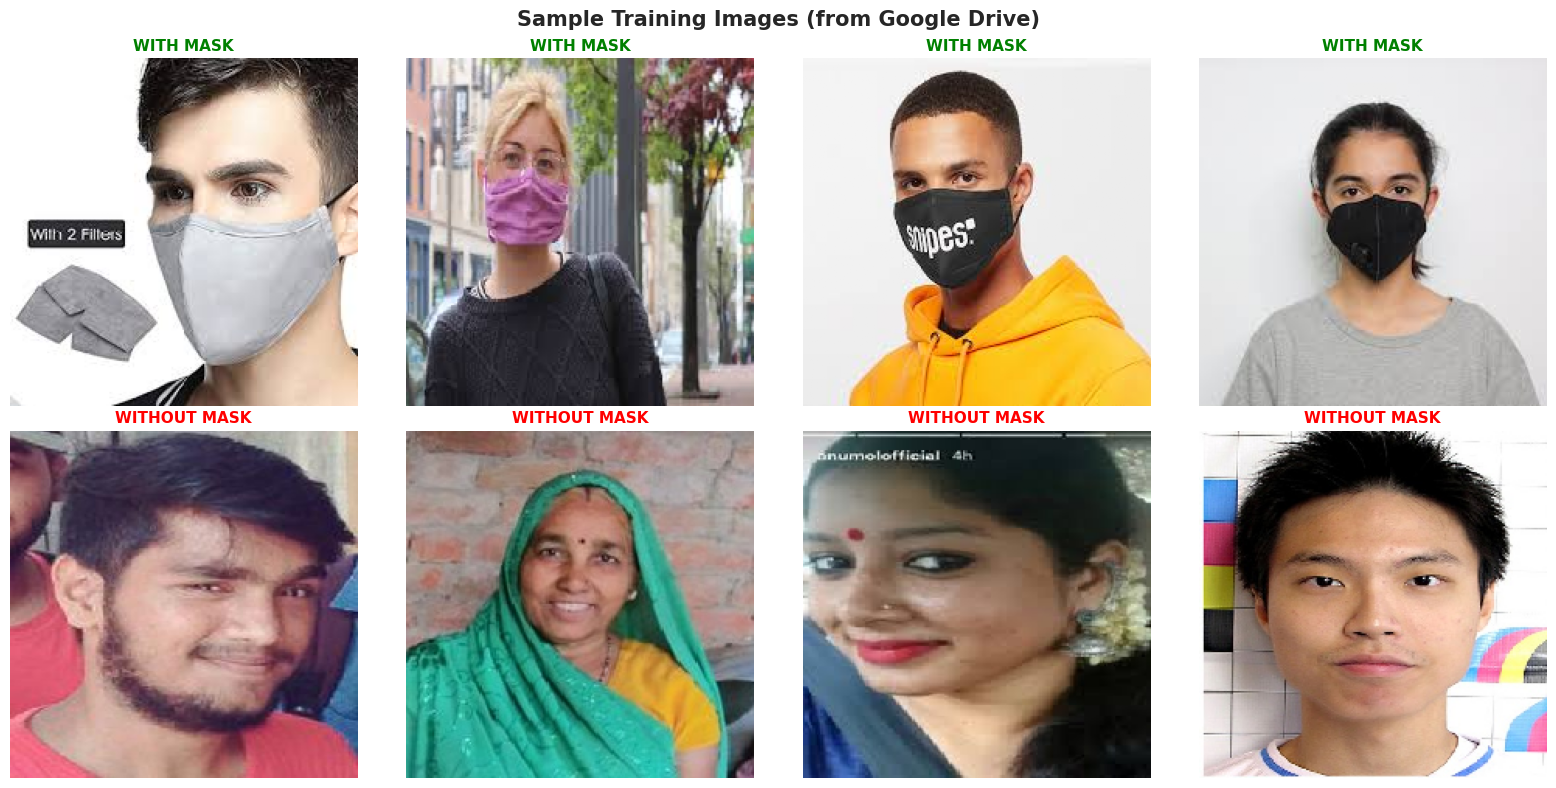

In [3]:
# ============================================================
# 1.3 Visualize Sample Training Images
# ============================================================

class_names = ['Without Mask', 'With Mask']
mask_idx = np.where(y_train == 1)[0]
nomask_idx = np.where(y_train == 0)[0]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Training Images (from Google Drive)', fontsize=15, fontweight='bold')

for i, idx in enumerate(np.random.choice(mask_idx, 4, replace=False)):
    axes[0, i].imshow(X_train[idx])
    axes[0, i].set_title('WITH MASK', color='green', fontweight='bold', fontsize=11)
    axes[0, i].axis('off')

for i, idx in enumerate(np.random.choice(nomask_idx, 4, replace=False)):
    axes[1, i].imshow(X_train[idx])
    axes[1, i].set_title('WITHOUT MASK', color='red', fontweight='bold', fontsize=11)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## 2. Custom CNN Architecture

### Key: Augmentation is INSIDE the model

We put augmentation layers **inside** the model itself. These layers:
- **During training** (`model.fit`): Apply random flips, rotations, zooms
- **During prediction** (`model.predict`): Do nothing (pass images through unchanged)

This means we don't need any separate augmentation pipeline!

| Block | Filters | Output | Purpose |
|-------|---------|--------|---------|
| 1 | 32 | 112×112 | Edges, textures |
| 2 | 64 | 56×56 | Contours, patterns |
| 3 | 128 | 28×28 | Face parts, mask shapes |
| 4 | 256 | 14×14 | Abstract features |

In [4]:
# ============================================================
# 2.1 Build the Model (with augmentation layers inside)
# ============================================================

def build_custom_cnn(input_shape=(224, 224, 3)):
    model = keras.Sequential([
        # ---- DATA AUGMENTATION (only active during training) ----
        layers.InputLayer(input_shape=input_shape),
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.04),       # ~15 degrees
        layers.RandomZoom(0.1),
        layers.RandomTranslation(0.1, 0.1),

        # ---- BLOCK 1: 32 filters ----
        layers.Conv2D(32, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),

        # ---- BLOCK 2: 64 filters ----
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),

        # ---- BLOCK 3: 128 filters ----
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),

        # ---- BLOCK 4: 256 filters ----
        layers.Conv2D(256, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),

        # ---- CLASSIFIER ----
        layers.GlobalAveragePooling2D(),
        layers.Dense(256), layers.BatchNormalization(), layers.ReLU(), layers.Dropout(0.5),
        layers.Dense(128), layers.BatchNormalization(), layers.ReLU(), layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ], name='Custom_CNN')

    return model

model = build_custom_cnn()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 224, 224, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 490,689 (1.87 MB)

 Trainable params: 488,961 (1.87 MB)

 Non-trainable params: 1,728 (6.75 KB)

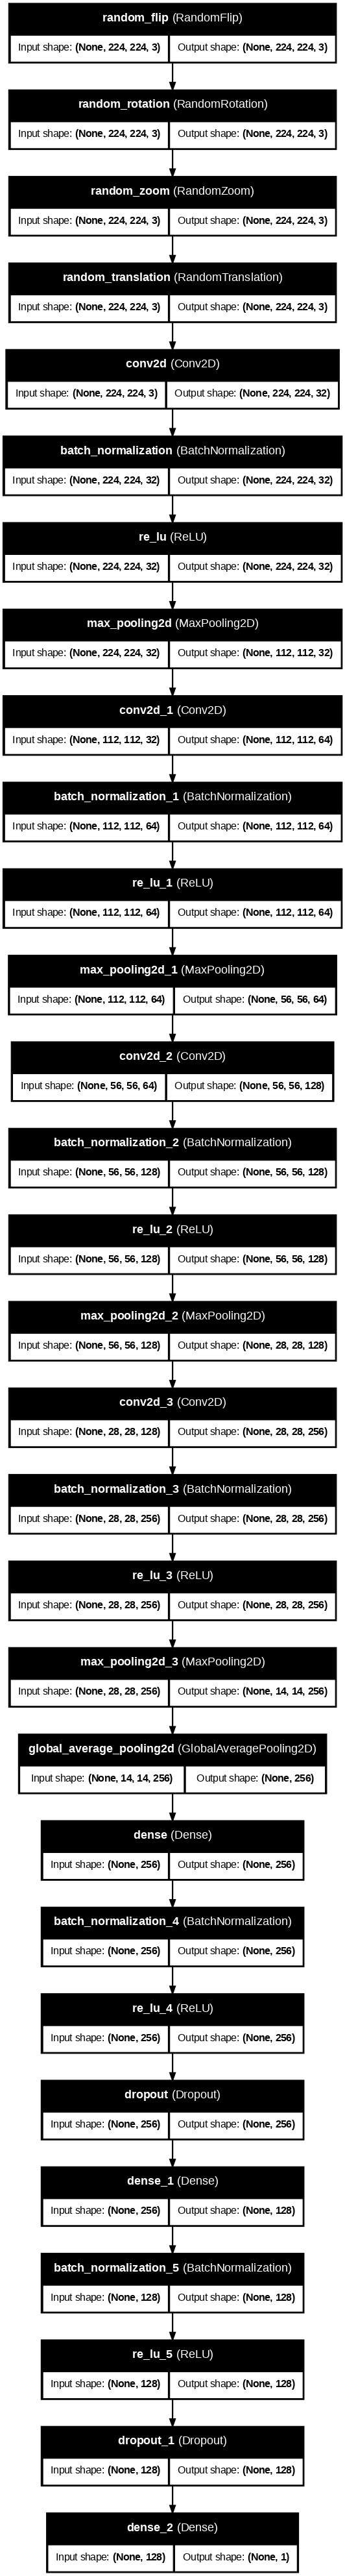

Total parameters: 490,689


In [5]:
# ============================================================
# 2.2 Visualize Architecture
# ============================================================

tf.keras.utils.plot_model(model, to_file='/content/cnn_arch.png',
                          show_shapes=True, show_layer_names=True, dpi=80)

from IPython.display import Image, display
display(Image(filename='/content/cnn_arch.png'))
print(f"Total parameters: {model.count_params():,}")

## 3. Training

### Memory-Safe Approach
We use a `keras.utils.Sequence` generator that reads training images **directly from the numpy array in batches of 32**. This avoids duplicating the entire training set in memory (which was causing the RAM crash).

```
Old (crashed):  np.load → tf.data copies ALL data → 2× RAM → 💥
New (works):    np.load → generator reads 32 at a time → 1× RAM → ✅
```

In [7]:
# ============================================================
# 3.1 Define Batch Generator (Memory-Safe)
# ============================================================
# This generator reads from the numpy array WITHOUT copying it.
# It feeds the model 32 images at a time instead of all at once.
# Augmentation happens inside the model, so the generator
# just needs to deliver raw batches.

class MaskDataGenerator(Sequence):
    """Memory-efficient batch generator that reads from numpy arrays."""

    def __init__(self, X, y, batch_size=32, shuffle=True):
        self.X = X              # reference, NOT a copy
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(X))
        if shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        return self.X[batch_idx], self.y[batch_idx]

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

BATCH_SIZE = 32
train_gen = MaskDataGenerator(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_gen   = MaskDataGenerator(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train generator: {len(train_gen)} batches of {BATCH_SIZE}")
print(f"Val generator:   {len(val_gen)} batches of {BATCH_SIZE}")
print(f"\nNo data duplication — generator reads directly from numpy arrays!")

Train generator: 166 batches of 32
Val generator:   36 batches of 32

No data duplication — generator reads directly from numpy arrays!


In [8]:
# ============================================================
# 3.2 Compile & Define Callbacks
# ============================================================

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

checkpoint_path = os.path.join(MODEL_DIR, 'custom_cnn_best.keras')

callback_list = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-7, verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=checkpoint_path, monitor='val_loss',
        save_best_only=True, verbose=1
    )
]

print("Compiled: Adam(lr=0.001), binary_crossentropy")
print("Callbacks: EarlyStopping(7), ReduceLR(3), Checkpoint")

Compiled: Adam(lr=0.001), binary_crossentropy
Callbacks: EarlyStopping(7), ReduceLR(3), Checkpoint


In [9]:
# ============================================================
# 3.3 Train!
# ============================================================

EPOCHS = 50

print(f"Training for up to {EPOCHS} epochs...")
print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Batch: {BATCH_SIZE}")
print(f"{'=' * 60}\n")

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callback_list,
    verbose=1
)

print(f"\n{'=' * 60}")
print(f"DONE! Epochs: {len(history.history['loss'])}")
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Best val_loss:     {min(history.history['val_loss']):.4f}")

Training for up to 50 epochs...
Train: 5,287 | Val: 1,133 | Batch: 32

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.7048 - loss: 0.5949
Epoch 1: val_loss improved from None to 1.24281, saving model to /content/drive/MyDrive/Face_Mask_Detection/models/custom_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Face_Mask_Detection/models/custom_cnn_best.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 36s 155ms/step - accuracy: 0.7235 - loss: 0.5657 - val_accuracy: 0.5075 - val_loss: 1.2428 - learning_rate: 0.0010
Epoch 2/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.7600 - loss: 0.5011
Epoch 2: val_loss improved from 1.24281 to 0.59513, saving model to /content/drive/MyDrive/Face_Mask_Detection/models/custom_cnn_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Face_Mask_Detection/models/custom_cnn_best.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 24s 144ms/step - accuracy: 0.7751 - loss: 0.4750 - val_accuracy: 0.6911 - val_loss: 0.5951 - learning_rate: 0.0010
Epoch 3/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - 

## 4. Training Curves

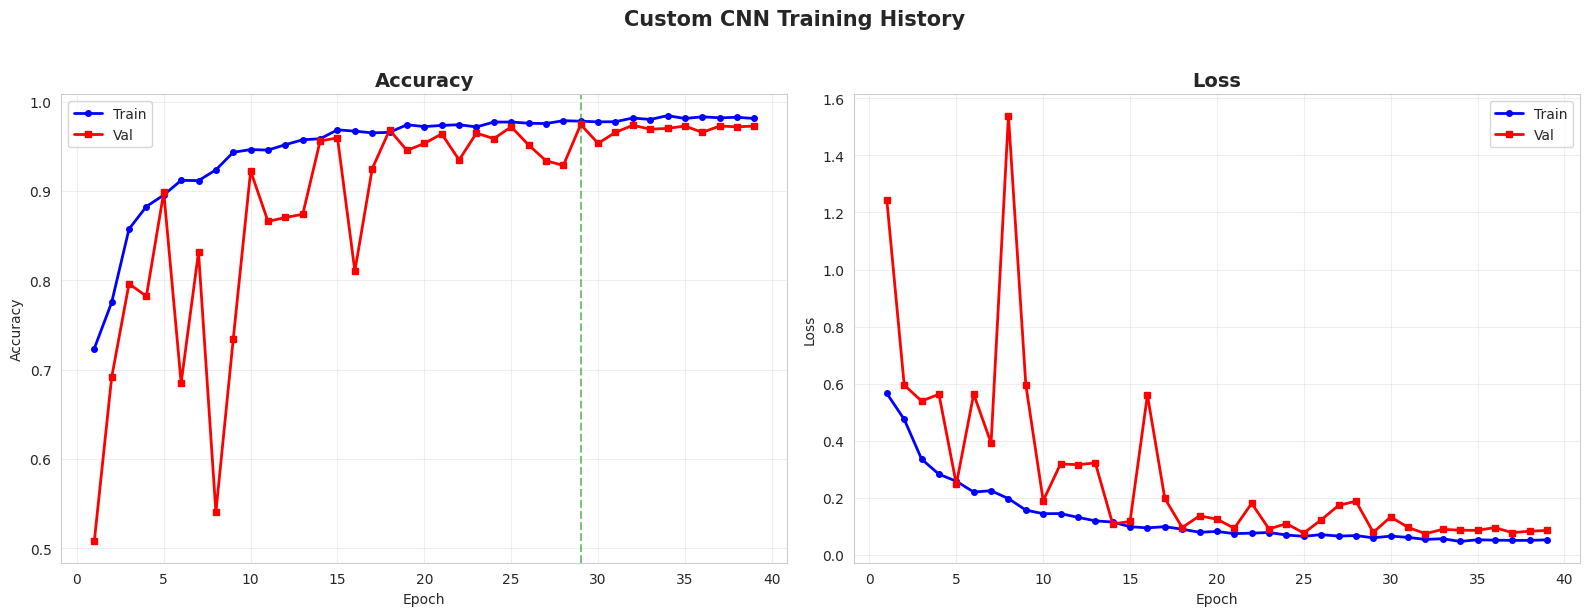

In [10]:
# ============================================================
# 4. Plot Training History
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ep = range(1, len(history.history['accuracy']) + 1)

axes[0].plot(ep, history.history['accuracy'], 'b-o', ms=4, lw=2, label='Train')
axes[0].plot(ep, history.history['val_accuracy'], 'r-s', ms=4, lw=2, label='Val')
axes[0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

best_e = np.argmax(history.history['val_accuracy']) + 1
axes[0].axvline(x=best_e, color='green', ls='--', alpha=0.5)

axes[1].plot(ep, history.history['loss'], 'b-o', ms=4, lw=2, label='Train')
axes[1].plot(ep, history.history['val_loss'], 'r-s', ms=4, lw=2, label='Val')
axes[1].set_title('Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Custom CNN Training History', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Evaluation on Test Set

In [11]:
# ============================================================
# 5.1 Test Accuracy
# ============================================================

test_loss, test_accuracy = model.evaluate(X_test, y_test, batch_size=32, verbose=1)
print(f"\nTest Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9682 - loss: 0.0791

Test Accuracy: 96.82%
Test Loss:     0.0791


36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step


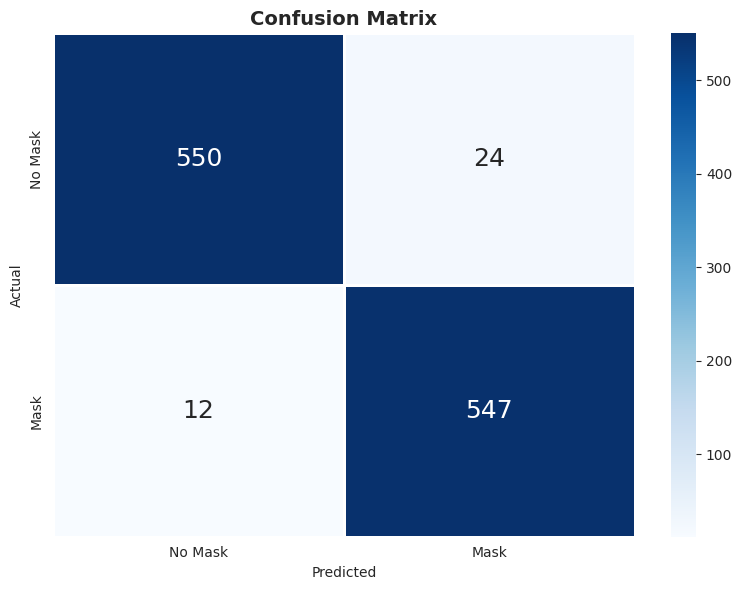

Correct predictions: 1097/1133 (96.8%)


In [12]:
# ============================================================
# 5.2 Confusion Matrix
# ============================================================

y_pred_prob = model.predict(X_test, batch_size=32, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Mask', 'Mask'],
            yticklabels=['No Mask', 'Mask'],
            annot_kws={'size': 18}, linewidths=1, ax=ax)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Correct predictions: {tn+tp}/{len(y_test)} ({(tn+tp)/len(y_test)*100:.1f}%)")

In [13]:
# ============================================================
# 5.3 Classification Report
# ============================================================

print(classification_report(y_test, y_pred,
                            target_names=['Without Mask', 'With Mask'],
                            digits=4))

              precision    recall  f1-score   support

Without Mask     0.9786    0.9582    0.9683       574
   With Mask     0.9580    0.9785    0.9681       559

    accuracy                         0.9682      1133
   macro avg     0.9683    0.9684    0.9682      1133
weighted avg     0.9684    0.9682    0.9682      1133



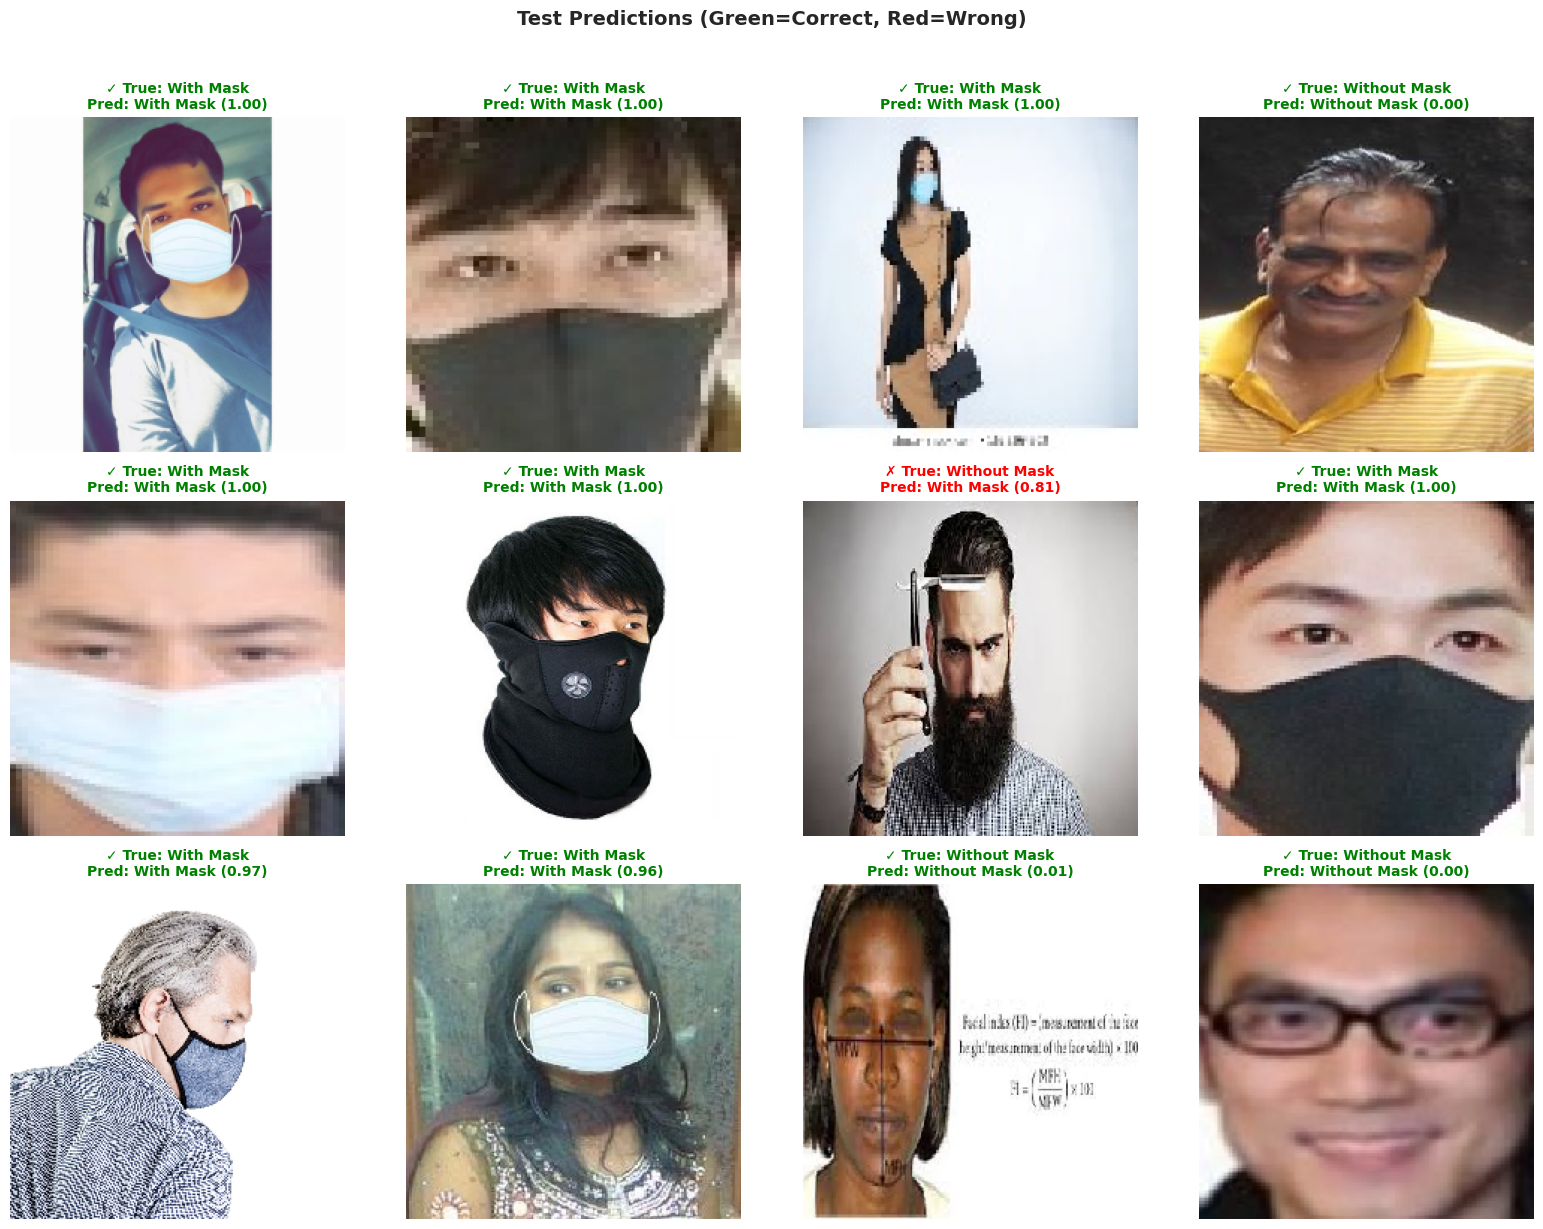

In [14]:
# ============================================================
# 5.4 Sample Test Predictions with Images
# ============================================================

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
idxs = np.random.choice(len(X_test), 12, replace=False)

for i, idx in enumerate(idxs):
    r, c = i//4, i%4
    axes[r,c].imshow(X_test[idx])

    true = int(y_test[idx])
    pred = y_pred[idx]
    conf = y_pred_prob[idx][0]
    ok = true == pred

    axes[r,c].set_title(
        f"{'✓' if ok else '✗'} True: {class_names[true]}\n"
        f"Pred: {class_names[pred]} ({conf:.2f})",
        fontsize=10, color='green' if ok else 'red', fontweight='bold')
    axes[r,c].axis('off')

plt.suptitle('Test Predictions (Green=Correct, Red=Wrong)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Save Model

In [15]:
# ============================================================
# 6. Save to Google Drive
# ============================================================

save_path = os.path.join(MODEL_DIR, 'custom_cnn.keras')
model.save(save_path)

print(f"Model saved: {save_path}")
print(f"Size: {os.path.getsize(save_path)/(1024**2):.1f} MB")
print(f"Test accuracy: {test_accuracy*100:.2f}%")
print(f"\n✅ Next: Run Notebook 3 (Transfer Learning)")

Model saved: /content/drive/MyDrive/Face_Mask_Detection/models/custom_cnn.keras
Size: 5.7 MB
Test accuracy: 96.82%

✅ Next: Run Notebook 3 (Transfer Learning)


---

## Summary

### Data Flow
```
Notebook 1 saved .npy files to Google Drive
    ↓
This notebook: np.load() → Batch Generator (32 at a time) → Model
    ↓                                                         ↓
No data duplication!                              Augmentation layers inside model
    ↓                                             (only active during training)
Peak RAM: ~4.5 GB ✅
```

### Next: Notebook 3 (Transfer Learning)

---